## Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, \
    classification_report
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

import pandas as pd

%matplotlib inline

sns.set_theme()


## Carga del dataset

In [2]:
# 1. Cargar los datasets
df_train = pd.read_csv('./../../../dataset/oulad/generated/dataset_train_2013_enriquecido.csv')
df_test = pd.read_csv('./../../../dataset/oulad/generated/dataset_test_2014_enriquecido.csv')

# ====================================================================
# UNDERSAMPLING AL 50% EN EL CONJUNTO DE ENTRENAMIENTO (2013)
# ====================================================================
# Separamos las clases del año 2013
df_train_exito = df_train[df_train['target_burnout'] == 0]
df_train_riesgo = df_train[df_train['target_burnout'] == 1]

# Reducimos la clase de éxito a la mitad (50%) aleatoriamente con semilla fija
df_train_exito_reducido = df_train_exito.sample(frac=0.5, random_state=42)

# Volvemos a unir y mezclamos (shuffle) para que el algoritmo no lea en orden
df_train = pd.concat([df_train_exito_reducido, df_train_riesgo]).sample(frac=1, random_state=42)
# ====================================================================

# 2. Separar características (X) y variable objetivo (y)
X_train = df_train.drop(columns=['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']

X_test = df_test.drop(columns=['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

# 3. Comprobación de la distribución tras el balanceo
print("--- DISTRIBUCIÓN TRAS EL BALANCEO (DATASET ENRIQUECIDO) ---")
print(f"Train 2013 - Total: {len(X_train)} | Riesgo (1): {y_train.sum()} | Éxito (0): {len(y_train) - y_train.sum()}")
print(f"Test 2014  - Total: {len(X_test)} | Riesgo (1): {y_test.sum()} | Éxito (0): {len(y_test) - y_test.sum()}")
print(f"\nNúmero de características (columnas) para el modelo: {X_train.shape[1]}")

--- DISTRIBUCIÓN TRAS EL BALANCEO (DATASET ENRIQUECIDO) ---
Train 2013 - Total: 7245 | Riesgo (1): 3348 | Éxito (0): 3897
Test 2014  - Total: 10801 | Riesgo (1): 3693 | Éxito (0): 7108

Número de características (columnas) para el modelo: 29


## Construcción y Entrenamiento del Pipeline

In [3]:
# 1. Definición de columnas actualizadas al dataset enriquecido
cat_cols = ['highest_education']

num_cols = [
    'num_of_prev_attempts', 'studied_credits',
    'total_clicks_90d', 'media_clicks_semanales', 'total_dias_activos',
    'semanas_con_actividad', 'semanas_actividad_plena', 'max_clicks_1_dia',
    'semanas_sin_clicks', 'dias_sin_clicks_90d',
    'entregas_realizadas_90d', 'nota_media_90d', 'retraso_medio_dias', 'total_entregas_tardias',
    'clicks_semana_0', 'clicks_semana_1', 'clicks_semana_2', 'clicks_semana_3',
    'clicks_semana_4', 'clicks_semana_5', 'clicks_semana_6', 'clicks_semana_7',
    'clicks_semana_8', 'clicks_semana_9', 'clicks_semana_10', 'clicks_semana_11',
    'clicks_semana_12'
]

# 2. Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 3. Pipeline Base SVM
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

# 4. Entrenar modelo
svm_pipeline.fit(X_train, y_train)

# 5. Generar predicciones
y_pred = svm_pipeline.predict(X_test)

print("¡Entrenamiento de SVM finalizado con éxito!")

¡Entrenamiento de SVM finalizado con éxito!


## Evaluación y Gráficas de Rendimiento

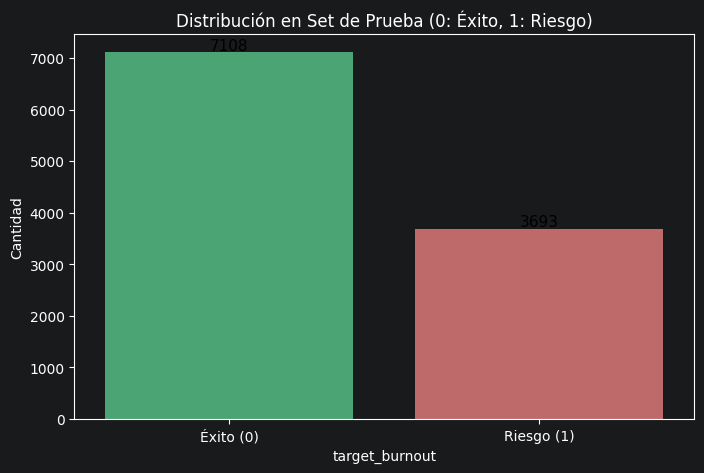

--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: 0.47) ---
              precision    recall  f1-score   support

           0       0.89      0.81      0.84      7108
           1       0.68      0.80      0.74      3693

    accuracy                           0.81     10801
   macro avg       0.79      0.81      0.79     10801
weighted avg       0.82      0.81      0.81     10801



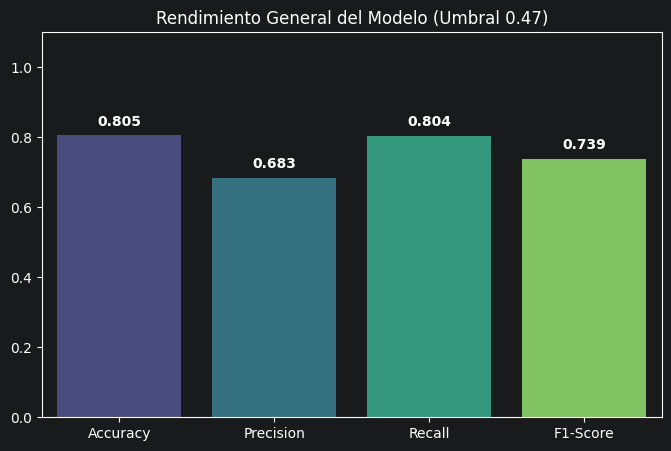

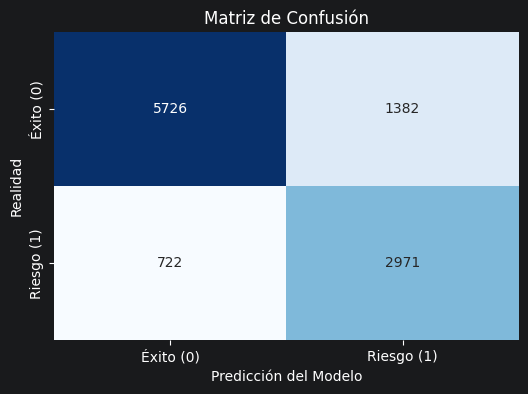

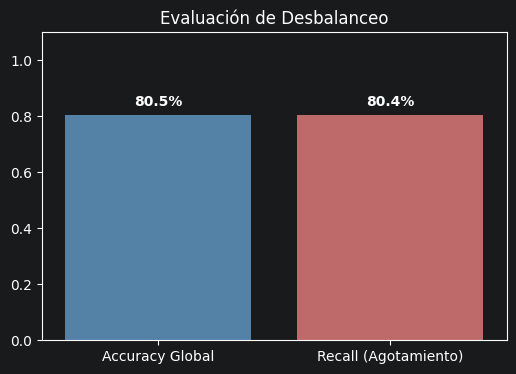

In [7]:
y_probs = svm_pipeline.predict_proba(X_test)[:, 1]

# UMBRAL PERMISIVO
umbral_permisivo = 0.47
y_pred = (y_probs >= umbral_permisivo).astype(int)


fig1 = plt.figure(figsize=(8, 5))

ax1 = sns.countplot(x=y_test, hue=y_test, palette=['#3CB371', '#CD5C5C'], legend=False)
plt.title('Distribución en Set de Prueba (0: Éxito, 1: Riesgo)')
plt.xticks(ticks=[0, 1], labels=['Éxito (0)', 'Riesgo (1)'])
plt.ylabel('Cantidad')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# ==========================================
# CÁLCULO DE MÉTRICAS Y REPORTE
# ==========================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: {umbral_permisivo}) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# GRÁFICO 2: Visualización de Métricas Habituales
# ==========================================
fig2 = plt.figure(figsize=(8, 5))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
ax2 = sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='viridis', legend=False)
plt.title(f'Rendimiento General del Modelo (Umbral {umbral_permisivo})')
plt.ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')
plt.show()

# ==========================================
# GRÁFICO 3: Matriz de Confusión
# ==========================================
cm = confusion_matrix(y_test, y_pred)

fig3 = plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

# ==========================================
# GRÁFICO 4: Accuracy Global vs Recall Minoritario
# ==========================================
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

fig4 = plt.figure(figsize=(6, 4))

metric_names_comp = ['Accuracy Global', 'Recall (Agotamiento)']
metric_values_comp = [acc, burnout_recall]
ax4 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, palette=['#4682B4', '#CD5C5C'],
                  legend=False)
plt.title('Evaluación de Desbalanceo')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax4.text(i, v + 0.02, f"{v * 100:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.show()

## Busqueda de hiperparametros

In [5]:
# ==========================================
# 1. CONFIGURACIÓN DEL ESPACIO DE BÚSQUEDA (SVM)
# ==========================================
param_grid_svm = {
    # C: Coste de equivocarse
    'classifier__C': [0.1, 1, 10],

    # kernel: La forma matemática de proyectar los datos. ('linear', 'rbf')
    'classifier__kernel': ['linear', 'rbf'],

    # class_weight: Comparamos el balanceo matemático automático frente a darle un peso fijo al riesgo.
    'classifier__class_weight': ['balanced', {0: 1, 1: 3}, {0: 1, 1: 5}],

    # gamma: (Solo aplica a RBF)
    'classifier__gamma': ['scale', 'auto']
}

print("Iniciando Grid Search para SVM...")
print("Nota: SVM requiere alta carga computacional. Este proceso puede tardar bastante tiempo.")

# ==========================================
# 2. EJECUCIÓN DE LA BÚSQUEDA
# ==========================================
# estimator
grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2 #
)

grid_search_svm.fit(X_train, y_train)

# ==========================================
# 3. RESULTADOS DE LA OPTIMIZACIÓN
# ==========================================
print("\n" + "=" * 50)
print("¡BÚSQUEDA SVM FINALIZADA!")
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_svm.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")
print("=" * 50)

# ==========================================
# 4. PRUEBA RÁPIDA CON EL MODELO GANADOR Y BARRIDO
# ==========================================
mejor_modelo_svm = grid_search_svm.best_estimator_

# Extraemos las probabilidades de la clase 1 (Riesgo)
y_probs_svm = mejor_modelo_svm.predict_proba(X_test)[:, 1]

# Probamos con el umbral clásico del 0.50 como base
umbral_base = 0.50
y_pred_svm = (y_probs_svm >= umbral_base).astype(int)

print(f"\n--- REPORTE DEL MEJOR MODELO SVM (Umbral: {umbral_base}) ---")
print(classification_report(y_test, y_pred_svm, zero_division=0))

print("\n" + "=" * 65)
print(" BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO SVM GANADOR")
print("=" * 65)
print(f"{'Umbral':<8} | {'Accuracy Global':<18} | {'Recall (Riesgo)':<18} | {'Precisión (Riesgo)':<18}")
print("-" * 65)

# Barrido diferencial para encontrar el equilibrio exacto
umbrales_prueba = np.arange(0.30, 0.85, 0.05)

for u in umbrales_prueba:
    y_pred_temp = (y_probs_svm >= u).astype(int)

    acc = accuracy_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp, zero_division=0)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)

    print(f"{u:.2f}     | {acc * 100:>5.1f}%             | {rec * 100:>5.1f}%             | {prec * 100:>5.1f}%")

Iniciando Grid Search para SVM...
Nota: SVM requiere alta carga computacional. Este proceso puede tardar bastante tiempo.
Fitting 3 folds for each of 36 candidates, totalling 108 fits

¡BÚSQUEDA SVM FINALIZADA!
Mejores hiperparámetros encontrados:
 - C: 10
 - class_weight: balanced
 - gamma: auto
 - kernel: rbf

--- REPORTE DEL MEJOR MODELO SVM (Umbral: 0.5) ---
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      7108
           1       0.69      0.79      0.74      3693

    accuracy                           0.81     10801
   macro avg       0.78      0.80      0.79     10801
weighted avg       0.82      0.81      0.81     10801


 BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO SVM GANADOR
Umbral   | Accuracy Global    | Recall (Riesgo)    | Precisión (Riesgo)
-----------------------------------------------------------------
0.30     |  70.2%             |  87.8%             |  54.0%
0.35     |  73.8%             |  85.9%             |  5